In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

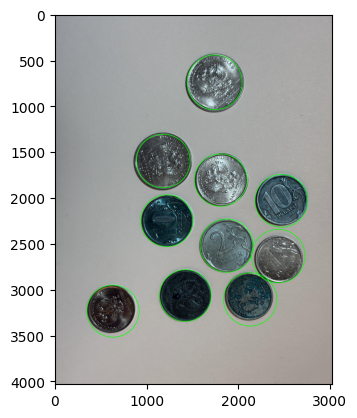

In [19]:
img_path = 'D:/practice 2nd year/Project/raw/scenes/IMG_3896.JPG'


# img_path = 'D:/practice 2nd year/Project/raw/singles/IMG_3855.JPG'



image = cv2.imread(img_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray, (9, 9), 2)

# Для нескольких
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=560,
    param1=130,
    param2=20,
    minRadius=280,
    maxRadius=300
)

#Для одной

# circles = cv2.HoughCircles(
#     gray,
#     cv2.HOUGH_GRADIENT,
#     dp=1,
#     minDist=1000,
#     param1=130,
#     param2=20,
#     minRadius=500,
#     maxRadius=800
# )

circles = np.uint16(np.around(circles))

img_circles = image.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))

    # Рисуем каждый найденный круг
    for i in circles[0, :]:
        # Рисуем окружность (контур круга)
        cv2.circle(img_circles, (i[0], i[1]), i[2], (0, 255, 0), 5)

        # Рисуем центр круга
        cv2.circle(img_circles, (i[0], i[1]), 2, (0, 0, 255), 1)

plt.imshow(img_circles)

In [24]:
def crop_coin(image, x, y, r, margin=15):
    x1 = max(0, x - r - margin)
    y1 = max(0, y - r - margin)

    x2 = min(image.shape[1], x + r + margin)
    y2 = min(image.shape[0], y + r + margin)

    return image[y1:y2, x1:x2]

In [27]:
coins = []
for c in circles[0]:
    x, y, r = c

    coin = crop_coin(image, x, y, r)
    coin = cv2.resize(coin, (224, 224))
    coins.append(coin)
print(len(coins))

10
